# CSC699 LoRA Fine-Tuning v3 (full plan)

Implements the LoRA Colab rewrite plan: production prompt parity, **completion-only SFT**, v18.1 allowlist + **STIX deprecation remap**, summary normalization, dedupe, **head cap** + tail oversample + inverse-rarity duplicates, synthetic RAG, optional `data/mapped` shard, **macro-F1 early stopping**, audit **CSV**, co-occurrence **heatmap**, collapse metrics (KL, diversity, mispairs), optional **v2 adapter A/B**, failure buckets.

**Output:** `final_adapter_v3`. Regenerate this file with `python gen_v3_notebook.py` after editing `gen_v3_notebook.py`.


## 1. Environment installs

In [1]:
!pip install -q transformers datasets accelerate bitsandbytes peft trl sentencepiece

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 32.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 697.4/697.4 kB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 527.0/527.0 kB 40.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 48.9/48.9 MB 48.6 MB/s eta 0:00:00


## 2. Auth & Drive

In [2]:
from huggingface_hub import notebook_login

notebook_login()

from google.colab import drive

drive.mount("/content/drive")

DRIVE_REPO_ROOT = "/content/drive/MyDrive/CSC699/Project/LastMile-Sec"
MAPPED_JSON_DIR = "/content/drive/MyDrive/CSC699/Project/LastMile-Sec/data/mapped"
ATTACK_CORPUS_LOCAL = "/content/drive/MyDrive/CSC699/Project/enterprise-attack-18.1.json"
OUTPUT_DIR = "/content/drive/MyDrive/CSC699/HF/siem-finetuned-v3"
ADAPTER_SAVE_PATH = "/content/drive/MyDrive/CSC699/HF/final_adapter_v3"
# Optional: set to a v2 adapter dir on Drive to compare after training
ADAPTER_V2_COMPARE_PATH = "/content/drive/MyDrive/CSC699/HF/final_adapter_v2"
AUDIT_EXPORT_DIR = "/content/drive/MyDrive/CSC699/HF/training_audit_v3"


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:93: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Mounted at /content/drive


## 3. ATT&CK bundle, allowlist, **deprecation remap**, summary normalize

**Anti-clustering:** remap revoked IDs to successors from STIX `revoked-by` so labels stay in v18.1 space; drop only what cannot be mapped.

In [4]:
import ast
import csv
import json
import math
import random
import re
import urllib.request
from collections import Counter, defaultdict
from pathlib import Path

import numpy as np
import pandas as pd
import torch
from datasets import Dataset, concatenate_datasets, load_dataset
from peft import LoraConfig, PeftModel, get_peft_model, prepare_model_for_kbit_training
from transformers import AutoModelForCausalLM, AutoTokenizer, BitsAndBytesConfig, EarlyStoppingCallback
from trl import SFTConfig, SFTTrainer

ATTACK_VERSION = "18.1"
MAX_TECHNIQUES_PER_FINDING = 5
RAG_FRACTION = 0.18
SEED = 42
# Rebalancing (plan): cap how many train rows may carry each tag (head suppression)
MAX_ROWS_PER_TAG = 450
# Rare-tag tail oversample
RARE_TAG_THRESHOLD = 80
TAIL_MAX_DUPES_PER_ROW = 12
# Approximate inverse-frequency weighting: extra copies for rows whose min-tag count is low
INVERSE_FREQ_MAX_EXTRA = 3
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)


def load_attack_bundle_raw(corpus_path):
    path = Path(corpus_path) if corpus_path else None
    if path and path.is_file():
        return path.read_text(encoding="utf-8")
    url = (
        "https://raw.githubusercontent.com/mitre-attack/attack-stix-data/master/"
        f"enterprise-attack/enterprise-attack-{ATTACK_VERSION}.json"
    )
    print("Downloading ATT&CK bundle:", url)
    with urllib.request.urlopen(url, timeout=180) as r:
        return r.read().decode("utf-8")


ATTACK_BUNDLE_RAW = load_attack_bundle_raw(
    ATTACK_CORPUS_LOCAL if Path(ATTACK_CORPUS_LOCAL).is_file() else None
)
ATTACK_BUNDLE = json.loads(ATTACK_BUNDLE_RAW)


def allowlist_from_bundle(bundle):
    allow = set()
    for obj in bundle.get("objects", []):
        if obj.get("type") != "attack-pattern":
            continue
        for ext in obj.get("external_references") or []:
            rid = ext.get("external_id") or ""
            if rid.startswith("T") and len(rid) > 1 and rid[1].isdigit():
                allow.add(rid.upper())
    return allow


def deprecation_remap_from_bundle(bundle):
    # Map deprecated external_id -> successor via STIX revoked-by relationships.
    stix_to_tid = {}
    for obj in bundle.get("objects", []):
        if obj.get("type") != "attack-pattern":
            continue
        oid = obj.get("id")
        if not oid:
            continue
        for ext in obj.get("external_references") or []:
            rid = ext.get("external_id") or ""
            if rid.startswith("T") and len(rid) > 1 and rid[1].isdigit():
                stix_to_tid[oid] = rid.upper()
                break
    remap = {}
    for obj in bundle.get("objects", []):
        if obj.get("type") != "relationship":
            continue
        if obj.get("relationship_type") != "revoked-by":
            continue
        src = obj.get("source_ref")
        tgt = obj.get("target_ref")
        old_tid = stix_to_tid.get(src)
        new_tid = stix_to_tid.get(tgt)
        if old_tid and new_tid and old_tid != new_tid:
            remap[old_tid] = new_tid
    print("STIX revoked-by remap entries:", len(remap))
    return remap


ALLOWLIST = allowlist_from_bundle(ATTACK_BUNDLE)
DEPRECATION_REMAP = deprecation_remap_from_bundle(ATTACK_BUNDLE)
print(f"Loaded {len(ALLOWLIST)} technique IDs in v{ATTACK_VERSION} allowlist.")

# Optional manual overrides (dataset quirks not in STIX)
EXTRA_DEPRECATION_REMAP = {}
DEPRECATION_REMAP = {**DEPRECATION_REMAP, **EXTRA_DEPRECATION_REMAP}


def root_id(tid):
    return tid.upper().split(".", 1)[0]


def chain_remap_tid(tid):
    u = tid.upper().strip()
    for _ in range(8):
        nxt = DEPRECATION_REMAP.get(u)
        if nxt is None:
            nxt = DEPRECATION_REMAP.get(root_id(u))
        if not nxt or nxt == u:
            break
        u = nxt
    return u


def is_allowed_id(tid, allow):
    u = tid.upper().strip()
    if u in allow:
        return True
    return root_id(u) in allow


def normalize_summary_text(text):
    # Lightweight normalization toward short technical-summary style (no LLM).
    if not text:
        return ""
    t = text.replace("\r\n", "\n").strip()
    t = re.sub(r"\s+", " ", t)
    t = re.sub(
        r"(?i)^(summary:|description:|abstract:)\s*",
        "",
        t,
    )
    if len(t) > 2500:
        t = t[:2500] + "…"
    return t


def normalize_tag_list(tags):
    out, seen = [], set()
    for t in tags or []:
        if not t:
            continue
        u = chain_remap_tid(str(t))
        if not u.startswith("T"):
            continue
        if not is_allowed_id(u, ALLOWLIST):
            continue
        if u not in seen:
            seen.add(u)
            out.append(u)
        if len(out) >= MAX_TECHNIQUES_PER_FINDING:
            break
    return out


def format_mitre_list(tags):
    return "['" + "','".join(tags) + "']\n"


STIX revoked-by remap entries: 132
Loaded 835 technique IDs in v18.1 allowlist.


## 4. Load dataset, audit, **CSV export**, co-occurrence **heatmap** (sampled)

**Anti-clustering:** inspect long-tail structure; persist label counts for reproducibility.

Loading tumeteor/Security-TTP-Mapping ...
Unique raw tags (train): 499
Top 15 raw tags: [('T1105', 595), ('T1027', 524), ('T1082', 451), ('T1083', 400), ('T1140', 332), ('T1547.001', 330), ('T1070.004', 320), ('T1016', 319), ('T1057', 314), ('T1071.001', 304), ('T1059.003', 304), ('T1059.001', 269), ('T1059', 227), ('T1053.005', 219), ('T1033', 218)]
ATTACK_VERSION: 18.1 | enterprise-attack-18.1.json / config.ATTACK_VERSION


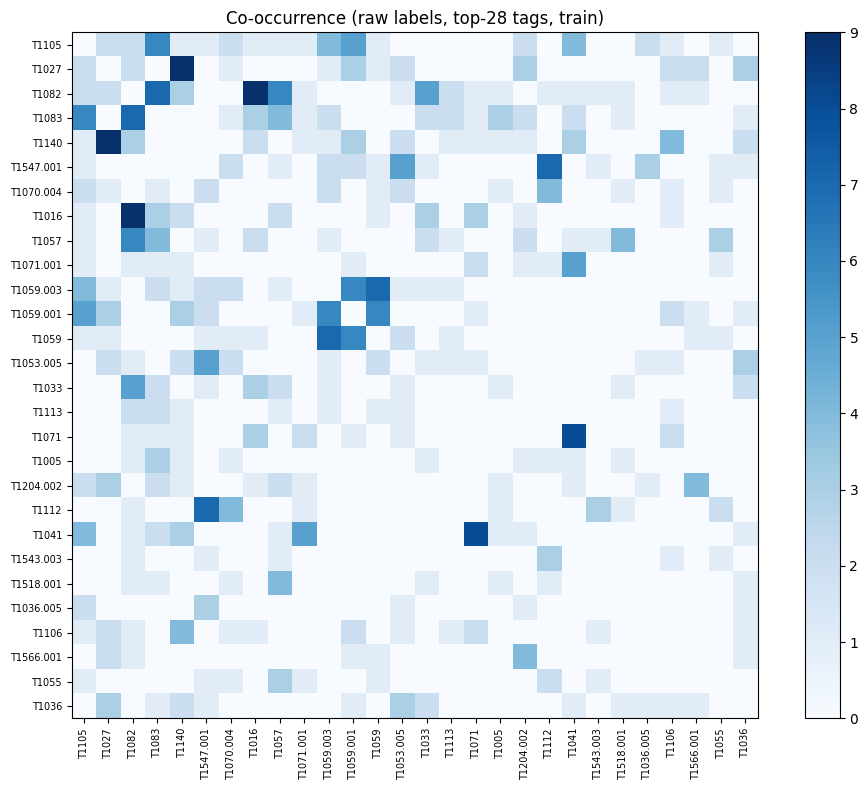

Saved: /content/drive/MyDrive/CSC699/HF/training_audit_v3/cooccurrence_raw_top_tags.png


In [6]:
import ast
import matplotlib.pyplot as plt
import numpy as np
from collections import Counter
from pathlib import Path

Path(AUDIT_EXPORT_DIR).mkdir(parents=True, exist_ok=True)

print("Loading tumeteor/Security-TTP-Mapping ...")
ds_raw = load_dataset("tumeteor/Security-TTP-Mapping")
ds_raw = ds_raw.rename_column("labels", "mitre_tags")

# Helper to safely parse the string "['T1057']" into a list ['T1057']
def parse_tags(tag_str):
    if not tag_str:
        return []
    try:
        parsed = ast.literal_eval(tag_str)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return []

flat_raw = []
for row in ds_raw["train"]:
    tags_list = parse_tags(row.get("mitre_tags"))
    for t in tags_list:
        flat_raw.append(str(t).upper())

hist_raw = Counter(flat_raw)
print("Unique raw tags (train):", len(hist_raw))
print("Top 15 raw tags:", hist_raw.most_common(15))

print("ATTACK_VERSION:", ATTACK_VERSION, "| enterprise-attack-18.1.json / config.ATTACK_VERSION")

# Co-occurrence heatmap (top-K frequent tags, train split, sampled pairs)
K_CO = min(28, len(hist_raw)) # Safety check in case there are fewer than 28 tags
top_tags = [t for t, _ in hist_raw.most_common(K_CO)]
tag_i = {t: i for i, t in enumerate(top_tags)}

mat = np.zeros((K_CO, K_CO), dtype=np.float32)
for row in ds_raw["train"]:
    tags_list = parse_tags(row.get("mitre_tags"))
    ts = sorted({str(x).upper() for x in tags_list if str(x).upper() in tag_i})
    for a in range(len(ts)):
        for b in range(a + 1, len(ts)):
            i, j = tag_i[ts[a]], tag_i[ts[b]]
            mat[i, j] += 1
            mat[j, i] += 1

fig, ax = plt.subplots(figsize=(10, 8))
im = ax.imshow(mat, cmap="Blues")

ax.set_xticks(range(K_CO))
ax.set_yticks(range(K_CO))
ax.set_xticklabels(top_tags, rotation=90, fontsize=7)
ax.set_yticklabels(top_tags, fontsize=7)
ax.set_title("Co-occurrence (raw labels, top-%d tags, train)" % K_CO)

plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.savefig(str(Path(AUDIT_EXPORT_DIR) / "cooccurrence_raw_top_tags.png"), dpi=120)
plt.show()

print("Saved:", Path(AUDIT_EXPORT_DIR) / "cooccurrence_raw_top_tags.png")

## 5. Filter, **dedupe**, **head cap**, tail oversample, **inverse-rarity** duplicates

**Anti-clustering:** suppress hyper-frequent tags, upsample tail and rare-tag rows.

In [8]:
import ast

def parse_tags(tag_str):
    if not tag_str:
        return []
    try:
        parsed = ast.literal_eval(tag_str)
        if isinstance(parsed, list):
            return parsed
    except (ValueError, SyntaxError):
        pass
    return []

def attach_normalized(example):
    # Parse the string into a real list before normalizing
    raw_tags = parse_tags(example.get("mitre_tags"))
    tags = normalize_tag_list(raw_tags)
    text_norm = normalize_summary_text(example.get("text1") or "")
    return {"tags_norm": tags, "text1_norm": text_norm}

train_ft = ds_raw["train"].map(attach_normalized)
val_ft = ds_raw["validation"].map(attach_normalized)
train_ft = train_ft.filter(lambda ex: len(ex["tags_norm"]) > 0)
val_ft = val_ft.filter(lambda ex: len(ex["tags_norm"]) > 0)

# Dedupe: identical normalized summary + label set
def dedupe_by_content(dataset):
    seen = set()
    keep_idx = []
    for i, row in enumerate(dataset):
        key = (row["text1_norm"], tuple(row["tags_norm"]))
        if key in seen:
            continue
        seen.add(key)
        keep_idx.append(i)
    return dataset.select(keep_idx)

train_ft = dedupe_by_content(train_ft)
print("Train rows after dedupe:", len(train_ft))

hist_n = Counter(t for row in train_ft for t in row["tags_norm"])
rows_by_tag = defaultdict(list)
for i, row in enumerate(train_ft):
    for t in row["tags_norm"]:
        rows_by_tag[t].append(i)


def cap_rows_per_tag(dataset, max_rows_per_tag):
    # Drop excess rows that contribute to the most overrepresented tags.
    tag_counts = Counter(t for row in dataset for t in row["tags_norm"])
    drop = set()
    for tag, cnt in tag_counts.most_common():
        if cnt <= max_rows_per_tag:
            break
        idxs = [i for i, row in enumerate(dataset) if tag in row["tags_norm"]]
        random.shuffle(idxs)
        for j in idxs[max_rows_per_tag:]:
            drop.add(j)
    if not drop:
        return dataset
    keep = [i for i in range(len(dataset)) if i not in drop]
    print(f"Head cap: dropped {len(drop)} rows (max {max_rows_per_tag} rows per tag)")
    return dataset.select(keep)

train_ft = cap_rows_per_tag(train_ft, MAX_ROWS_PER_TAG)
hist_n = Counter(t for row in train_ft for t in row["tags_norm"])

# Export filtered label histogram CSV
csv_path = Path(AUDIT_EXPORT_DIR) / "label_counts_train_filtered.csv"
with open(csv_path, "w", newline="", encoding="utf-8") as f:
    w = csv.writer(f)
    w.writerow(["technique_id", "row_count_tag_in_train"])
    for tid, c in hist_n.most_common():
        w.writerow([tid, c])
print("Wrote", csv_path)

print("Top 15 normalized tags (post cap):", hist_n.most_common(15))


def oversample_tail(dataset, max_per_tag=12, rare_threshold=80):
    tag_counts = Counter(t for row in dataset for t in row["tags_norm"])
    rare_tags = {t for t, c in tag_counts.items() if c < rare_threshold}
    extra_idx = []
    for i, row in enumerate(dataset):
        if any(t in rare_tags for t in row["tags_norm"]):
            m = max(tag_counts[u] for u in row["tags_norm"])
            extra_idx.extend([i] * min(max_per_tag, max(1, rare_threshold // max(m, 1))))
    if not extra_idx:
        return dataset
    aug = dataset.select(extra_idx)
    return concatenate_datasets([dataset, aug]).shuffle(seed=SEED)


def inverse_frequency_dupes(dataset, max_extra=3):
    # Extra copies for low-frequency tags (approx weighted sampling).
    tag_counts = Counter(t for row in dataset for t in row["tags_norm"])
    max_c = max(tag_counts.values()) if tag_counts else 1
    extras = []
    for i, row in enumerate(dataset):
        min_c = min(tag_counts[t] for t in row["tags_norm"])
        ratio = max_c / max(min_c, 1)
        n_extra = min(max_extra, max(0, int(math.log2(ratio)) - 1))
        extras.extend([i] * n_extra)
    if not extras:
        return dataset
    return concatenate_datasets([dataset, dataset.select(extras)]).shuffle(seed=SEED)

train_ft = oversample_tail(train_ft, TAIL_MAX_DUPES_PER_ROW, RARE_TAG_THRESHOLD)
train_ft = inverse_frequency_dupes(train_ft, INVERSE_FREQ_MAX_EXTRA)
print("Train rows after tail + inverse-freq dupes:", len(train_ft))


Map:   0%|          | 0/14936 [00:00<?, ? examples/s]

Map:   0%|          | 0/2630 [00:00<?, ? examples/s]

Filter:   0%|          | 0/14936 [00:00<?, ? examples/s]

Filter:   0%|          | 0/2630 [00:00<?, ? examples/s]

Train rows after dedupe: 14922
Head cap: dropped 206 rows (max 450 rows per tag)
Wrote /content/drive/MyDrive/CSC699/HF/training_audit_v3/label_counts_train_filtered.csv
Top 15 normalized tags (post cap): [('T1027', 450), ('T1105', 450), ('T1082', 448), ('T1083', 398), ('T1140', 331), ('T1547.001', 328), ('T1016', 319), ('T1070.004', 319), ('T1057', 312), ('T1071.001', 303), ('T1059.003', 300), ('T1059.001', 267), ('T1059', 223), ('T1033', 217), ('T1053.005', 216)]
Train rows after tail + inverse-freq dupes: 68601


## 6. Production template + alignment check

**Anti-clustering:** byte match with `prompts.py` avoids instruction skew.

In [9]:
NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE = "<s>\n### Instruction:\nYou are a cybersecurity assistant. Your task is to map a normalized finding summary to MITRE ATT&CK Enterprise technique IDs.\n\nOutput format: output ONLY a Python list of technique IDs in ATT&CK form, e.g. ['T1190'] or ['T1059.001', 'T1190']. At most 5 IDs. No prose, no JSON, no explanation.\n\nMapping discipline (critical):\n- Distinguish exposure (vulnerable, EOL, misconfiguration, missing patches) from observed adversary behavior (intrusion, malware, C2, credential theft). If the text only describes a weak or EOL public-facing service, prefer Initial Access (e.g. T1190 Exploit Public-Facing Application) when exploitation is plausible, and never invent Command and Control techniques.\n- T1102 (Web Service) and sub-techniques are for adversary use of web services for C2 or dead drops. Do NOT map to T1102.x unless the summary clearly describes C2, covert channels, beacons, callbacks, drop resolvers, or similar—not merely HTTP/HTTPS, nginx, or a generic web server.\n- Prefer precision over recall. If uncertain, output a shorter list or a single best ID.\n- Do not emit sub-technique IDs unless the evidence clearly supports that specificity.\n\n### Reference Examples from Database:\n{db_results}\n\n### Log:\n{technical_summary}\n\n### Response:\n"

def extract_local_template_from_prompts_py(repo_root):
    path = Path(repo_root) / "src" / "section2_report_map" / "prompts.py"
    if not path.is_file():
        raise FileNotFoundError(path)
    mod = ast.parse(path.read_text(encoding="utf-8"))
    for node in mod.body:
        if not isinstance(node, ast.ClassDef) or node.name != "AttackMapperPrompts":
            continue
        for sub in node.body:
            if isinstance(sub, ast.Assign) and isinstance(sub.targets[0], ast.Name):
                if sub.targets[0].id == "LOCAL_USER_PROMPT_TEMPLATE":
                    return sub.value.value
    raise ValueError("LOCAL_USER_PROMPT_TEMPLATE not found in prompts.py")

try:
    repo_tpl = extract_local_template_from_prompts_py(DRIVE_REPO_ROOT)
except Exception as e:
    print("Alignment check skipped:", e)
else:
    if repo_tpl != NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE:
        import difflib
        diff = difflib.unified_diff(
            repo_tpl.splitlines(),
            NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE.splitlines(),
            lineterm="",
            fromfile="prompts.py",
            tofile="notebook",
        )
        raise ValueError("Training template diverges from production:\n" + "\n".join(diff))
    print("OK: notebook matches AttackMapperPrompts.LOCAL_USER_PROMPT_TEMPLATE.")


Alignment check skipped: /content/drive/MyDrive/CSC699/Project/LastMile-Sec/src/section2_report_map/prompts.py


## 7. Synthetic RAG + `prompt` / `completion` (uses `text1_norm`)

In [10]:
EMPTY_DB = "No verified historical examples were found."


def build_tag_cooccurrence_index(dataset):
    idxs = defaultdict(list)
    for i, row in enumerate(dataset):
        for t in row["tags_norm"]:
            idxs[t].append(i)
    return idxs

TAG_TO_ROWS = build_tag_cooccurrence_index(train_ft)


def sample_db_results_train(example, row_index):
    if random.random() > RAG_FRACTION:
        return EMPTY_DB
    tags = example["tags_norm"]
    candidates = []
    for t in tags:
        for j in TAG_TO_ROWS.get(t, []):
            if j != row_index:
                candidates.append(j)
    if not candidates:
        return EMPTY_DB
    partner = train_ft[random.choice(candidates)]
    snippet = (partner.get("text1_norm") or "").strip()[:200]
    cur = (example.get("text1_norm") or "").strip()[:200]
    if snippet == cur:
        return EMPTY_DB
    ids_literal = format_mitre_list(tags).strip()
    return f"1. Summary: {snippet}...\n   Verified MITRE IDs: {ids_literal} (similarity=0.850)"


def row_to_train_pc(example, idx):
    summary = (example.get("text1_norm") or "").strip()
    db = sample_db_results_train(example, int(idx))
    prompt = NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE.format(db_results=db, technical_summary=summary)
    return {"prompt": prompt, "completion": format_mitre_list(example["tags_norm"])}


def row_to_val_pc(example, idx):
    summary = (example.get("text1_norm") or "").strip()
    prompt = NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE.format(db_results=EMPTY_DB, technical_summary=summary)
    return {"prompt": prompt, "completion": format_mitre_list(example["tags_norm"])}

train_pc = train_ft.map(row_to_train_pc, with_indices=True, remove_columns=train_ft.column_names)
val_pc = val_ft.map(row_to_val_pc, with_indices=True, remove_columns=val_ft.column_names)
print("Sample completion:", repr(train_pc[0]["completion"]))


Map:   0%|          | 0/68601 [00:00<?, ? examples/s]

Map:   0%|          | 0/2630 [00:00<?, ? examples/s]

Sample completion: "['T1083']\n"


## 8. Optional `data/mapped` shard

In [11]:
ENABLE_MAPPED_SHARD = True
PRODUCTION_SHARD_REPEATS = 4


def parse_raw_output_ids(raw):
    raw = raw or ""
    m = re.search(r"\[[^\]]*\]", raw)
    if not m:
        return []
    try:
        v = ast.literal_eval(m.group(0))
        if isinstance(v, list):
            return [str(x).upper() for x in v if x]
    except Exception:
        pass
    return []


def semantic_removed_all_ids(mapping):
    raw_ids = parse_raw_output_ids(mapping.get("raw_model_output") or "")
    final = [str(x).upper() for x in (mapping.get("mitre_ids") or []) if x]
    if not raw_ids or final:
        return False
    for issue in mapping.get("validation_issues") or []:
        if issue.get("gate") == "semantic":
            return True
    return False


def load_mapped_training_rows(mapped_dir):
    rows = []
    root = Path(mapped_dir)
    if not root.is_dir():
        print("Mapped dir missing:", mapped_dir)
        return rows
    for path in sorted(root.glob("*.json")):
        try:
            packet = json.loads(path.read_text(encoding="utf-8"))
        except Exception:
            continue
        for finding in packet.get("findings", []):
            meta = finding.get("metadata") or {}
            mapping = meta.get("mitre_mapping") or {}
            if not mapping.get("validation_passed", False):
                continue
            if semantic_removed_all_ids(mapping):
                continue
            mids = normalize_tag_list([str(x) for x in (mapping.get("mitre_ids") or []) if x])
            if not mids or len(mids) > MAX_TECHNIQUES_PER_FINDING:
                continue
            summary = normalize_summary_text(meta.get("technical_summary") or "")
            if not summary:
                continue
            rows.append({"text1_norm": summary, "tags_norm": mids})
    print("Production mapped rows:", len(rows))
    return rows


def row_to_train_from_mapped(example, idx):
    summary = (example.get("text1_norm") or "").strip()
    prompt = NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE.format(db_results=EMPTY_DB, technical_summary=summary)
    return {"prompt": prompt, "completion": format_mitre_list(example["tags_norm"])}

prod_rows = load_mapped_training_rows(MAPPED_JSON_DIR) if ENABLE_MAPPED_SHARD else []
if prod_rows:
    prod_ds = Dataset.from_list(prod_rows)
    prod_pc = prod_ds.map(row_to_train_from_mapped, with_indices=True, remove_columns=prod_ds.column_names)
    train_pc = concatenate_datasets([train_pc] + [prod_pc] * PRODUCTION_SHARD_REPEATS).shuffle(seed=SEED)
    print("Train rows after mapped shard:", len(train_pc))


Mapped dir missing: /content/drive/MyDrive/CSC699/Project/LastMile-Sec/data/mapped


## 9. Model + LoRA

In [12]:
model_id = "mistralai/Mistral-7B-Instruct-v0.1"

nf4_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_use_double_quant=True,
    bnb_4bit_compute_dtype=torch.bfloat16,
)

tokenizer = AutoTokenizer.from_pretrained(model_id, trust_remote_code=True)
tokenizer.pad_token = tokenizer.eos_token
tokenizer.padding_side = "right"

model = AutoModelForCausalLM.from_pretrained(
    model_id,
    quantization_config=nf4_config,
    device_map="auto",
    trust_remote_code=True,
)

model.gradient_checkpointing_enable()
model = prepare_model_for_kbit_training(model)

peft_config = LoraConfig(
    r=16,
    lora_alpha=16,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0.05,
    bias="none",
    task_type="CAUSAL_LM",
)
model = get_peft_model(model, peft_config)
model.print_trainable_parameters()


config.json:   0%|          | 0.00/571 [00:00<?, ?B/s]

tokenizer_config.json: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

tokenizer.model:   0%|          | 0.00/493k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/414 [00:00<?, ?B/s]

model.safetensors.index.json: 0.00B [00:00, ?B/s]

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

trainable params: 41,943,040 || all params: 7,283,675,136 || trainable%: 0.5758


## 10. **Macro-F1 SFTTrainer** + early stopping on `eval_macro_f1`

Runs a small generation pass on `eval_dataset` each `evaluate` call to compute **macro-F1** (subset for speed). `metric_for_best_model` drives checkpointing and `EarlyStoppingCallback`.

In [14]:
LABEL_VOCAB = sorted({t for row in val_ft for t in row["tags_norm"]})
MACRO_F1_EVAL_SAMPLES = 220


def parse_id_list(text):
    m = re.search(r"\[[^\]]*\]", text)
    if not m:
        return []
    try:
        v = ast.literal_eval(m.group(0))
        if isinstance(v, list):
            return [str(x).upper() for x in v]
    except Exception:
        pass
    return []


def multilabel_f1(golds, preds, all_labels):
    from sklearn.metrics import f1_score
    from sklearn.preprocessing import MultiLabelBinarizer

    mlb = MultiLabelBinarizer(classes=all_labels)
    Y = mlb.fit_transform([set(g) for g in golds])
    Yhat = mlb.transform([set(p) for p in preds])
    micro = f1_score(Y, Yhat, average="micro", zero_division=0)
    macro = f1_score(Y, Yhat, average="macro", zero_division=0)
    return micro, macro


def generation_macro_f1(trainer, n_samples):
    model = trainer.model
    tok = trainer.processing_class
    ds = trainer.eval_dataset
    n = min(n_samples, len(ds))
    golds = [val_ft[i]["tags_norm"] for i in range(n)]
    preds = []
    model.eval()
    device = next(model.parameters()).device
    for i in range(n):
        prompt = ds[i]["prompt"]
        inputs = tok(prompt, return_tensors="pt").to(device)
        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tok.pad_token_id,
                eos_token_id=tok.eos_token_id,
            )
        gen = tok.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
        preds.append(parse_id_list(gen))
    _, macro = multilabel_f1(golds, preds, LABEL_VOCAB)
    return macro


class MacroF1SFTTrainer(SFTTrainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        try:
            macro = generation_macro_f1(self, MACRO_F1_EVAL_SAMPLES)
        except Exception as e:
            print("macro-F1 eval skipped:", e)
            macro = 0.0
        metrics["eval_macro_f1"] = macro
        print("eval_macro_f1:", round(macro, 4))
        return metrics


args = SFTConfig(
    output_dir=OUTPUT_DIR,
    max_length=1024,
    max_steps=2400,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=5,
    learning_rate=3e-5,
    bf16=True,
    lr_scheduler_type="cosine",
    completion_only_loss=True,
    load_best_model_at_end=True,
    metric_for_best_model="eval_macro_f1",
    greater_is_better=True,
    report_to=[],
)

trainer = MacroF1SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    train_dataset=train_pc,
    eval_dataset=val_pc,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print("Trainer ready; best checkpoint by eval_macro_f1.")


Adding EOS to train dataset:   0%|          | 0/68601 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/68601 [00:00<?, ? examples/s]

Adding EOS to eval dataset:   0%|          | 0/2630 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2630 [00:00<?, ? examples/s]

Trainer ready; best checkpoint by eval_macro_f1.


In [18]:
# 1. FIX: Combine train and val sets so the binarizer knows all possible tags
LABEL_VOCAB = sorted(list(set(t for row in train_ft for t in row["tags_norm"]) | set(t for row in val_ft for t in row["tags_norm"])))
MACRO_F1_EVAL_SAMPLES = 220

def parse_id_list(text):
    m = re.search(r"\[[^\]]*\]", text)
    if not m:
        return []
    try:
        v = ast.literal_eval(m.group(0))
        if isinstance(v, list):
            return [str(x).upper() for x in v]
    except Exception:
        pass
    return []

def multilabel_f1(golds, preds, all_labels):
    from sklearn.metrics import f1_score
    from sklearn.preprocessing import MultiLabelBinarizer

    # 2. FIX: Lock the binarizer to the complete vocabulary before transforming
    mlb = MultiLabelBinarizer(classes=all_labels)
    mlb.fit([all_labels])

    Y = mlb.transform([set(g) for g in golds])
    Yhat = mlb.transform([set(p) for p in preds])
    micro = f1_score(Y, Yhat, average="micro", zero_division=0)
    macro = f1_score(Y, Yhat, average="macro", zero_division=0)
    return micro, macro

def generation_macro_f1(trainer, n_samples):
    model = trainer.model
    tok = trainer.processing_class
    ds = trainer.eval_dataset
    n = min(n_samples, len(ds))
    golds = [val_ft[i]["tags_norm"] for i in range(n)]
    preds = []
    model.eval()
    device = next(model.parameters()).device
    for i in range(n):
        prompt = ds[i]["prompt"]
        inputs = tok(prompt, return_tensors="pt").to(device)
        with torch.inference_mode():
            out = model.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tok.pad_token_id,
                eos_token_id=tok.eos_token_id,
            )
        gen = tok.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
        preds.append(parse_id_list(gen))
    _, macro = multilabel_f1(golds, preds, LABEL_VOCAB)
    return macro

class MacroF1SFTTrainer(SFTTrainer):
    def evaluate(self, eval_dataset=None, ignore_keys=None, metric_key_prefix="eval"):
        metrics = super().evaluate(eval_dataset, ignore_keys, metric_key_prefix)
        try:
            macro = generation_macro_f1(self, MACRO_F1_EVAL_SAMPLES)
        except Exception as e:
            print("macro-F1 eval skipped:", e)
            macro = 0.0
        # 3. FIX: Strip 'eval_' prefix so Hugging Face registers it correctly
        metrics["macro_f1"] = macro
        print("eval_macro_f1:", round(macro, 4))
        return metrics

args = SFTConfig(
    output_dir=OUTPUT_DIR,
    max_length=1024,
    max_steps=2400,
    per_device_train_batch_size=4,
    gradient_accumulation_steps=8,
    warmup_steps=100,
    logging_steps=50,
    eval_strategy="steps",
    eval_steps=200,
    save_strategy="steps",
    save_steps=200,
    save_total_limit=5,
    learning_rate=3e-5,
    bf16=True,
    lr_scheduler_type="cosine",
    completion_only_loss=True,
    load_best_model_at_end=True,
    metric_for_best_model="macro_f1", # 4. FIX: Must match the key precisely
    greater_is_better=True,
    report_to=[],
)

trainer = MacroF1SFTTrainer(
    model=model,
    processing_class=tokenizer,
    args=args,
    train_dataset=train_pc,
    eval_dataset=val_pc,
    callbacks=[EarlyStoppingCallback(early_stopping_patience=2)],
)
print("Trainer ready; best checkpoint by eval_macro_f1.")

Tokenizing train dataset:   0%|          | 0/68601 [00:00<?, ? examples/s]

Tokenizing eval dataset:   0%|          | 0/2630 [00:00<?, ? examples/s]

Trainer ready; best checkpoint by eval_macro_f1.


## 11. Debug batch (`-100` masking)

In [15]:
batch = next(iter(trainer.get_train_dataloader()))
labels = batch["labels"][0].tolist()
print("First 80 labels:", labels[:80])
if labels[:40].count(-100) < 20:
    print("WARNING: early positions not mostly -100")
else:
    print("OK: prompt region mostly masked.")


First 80 labels: [-100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100, -100]
OK: prompt region mostly masked.


## 12. Train + save

In [16]:
trainer.train()
trainer.model.save_pretrained(ADAPTER_SAVE_PATH)
tokenizer.save_pretrained(ADAPTER_SAVE_PATH)
manifest = {
    "attack_version": ATTACK_VERSION,
    "max_techniques": MAX_TECHNIQUES_PER_FINDING,
    "completion_only_loss": True,
    "metric_for_best_model": "eval_macro_f1",
    "rag_fraction": RAG_FRACTION,
    "max_rows_per_tag": MAX_ROWS_PER_TAG,
    "deprecation_remap_size": len(DEPRECATION_REMAP),
    "train_rows": len(train_pc),
    "val_rows": len(val_pc),
}
Path(ADAPTER_SAVE_PATH).mkdir(parents=True, exist_ok=True)
(Path(ADAPTER_SAVE_PATH) / "training_manifest.json").write_text(
    json.dumps(manifest, indent=2), encoding="utf-8"
)
print("Saved:", ADAPTER_SAVE_PATH)


The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 2}.


Step,Training Loss,Validation Loss
200,0.357522,0.386486
400,0.230636,0.305223
600,0.151795,0.273712
800,0.111348,0.237994
1000,0.085693,0.227885
1200,0.075722,0.216383
1400,0.054896,0.221395
1600,0.052343,0.208797
1800,0.051341,0.208225
2000,0.042726,0.204956


early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1013', 'T1047.001', 'T1053.001', 'T1053.004', 'T1055.003', 'T1070.002', 'T1078.001', 'T1127', 'T1127.001', 'T1135.001', 'T1187.001', 'T1195', 'T1204.003', 'T1546.001', 'T1546.002', 'T1552.002', 'T1555.002', 'T1584.001', 'T1584.002', 'T1592.002', 'T1595.001'] will be ignored
  warnings.warn(


eval_macro_f1: 0.0225


early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1037.001', 'T1057.001', 'T1057.002', 'T1057.003', 'T1204.003', 'T1490.001', 'T1550.001', 'T1550.004', 'T1552.005', 'T1563.001', 'T1574.005', 'T1583.005', 'T1584.001', 'T1584.006', 'T1588.005', 'T1591.001', 'T1592.001', 'T1592.002', 'T1595.001', 'T1608'] will be ignored
  warnings.warn(


...

eval_macro_f1: 0.0666


early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1003.008', 'T1059.002', 'T1110.002', 'T1126', 'T1170', 'T1539', 'T1550.004', 'T1552.002', 'T1584.001', 'T1588.005', 'T1588.006', 'T1595', 'T1609.001'] will be ignored
  warnings.warn(


eval_macro_f1: 0.0643


early stopping required metric_for_best_model, but did not find eval_macro_f1 so early stopping is disabled
/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1003.008', 'T1110.002', 'T1126', 'T1170', 'T1539', 'T1550.004', 'T1552.002', 'T1584.001', 'T1588.005', 'T1588.006', 'T1595'] will be ignored
  warnings.warn(


eval_macro_f1: 0.0673
Saved: /content/drive/MyDrive/CSC699/HF/final_adapter_v3


## 13. Full eval: micro/macro, **top1_fraction**, **diversity**, **KL**, **tail recall**, mispairs, **per-technique F1** (sample)

In [17]:


def kl_divergence(p, q, eps=1e-12):
    # KL-like divergence of normalized mass over shared keys.
    keys = sorted(set(p.keys()) | set(q.keys()))
    a = np.array([p.get(k, 0) + eps for k in keys], dtype=np.float64)
    b = np.array([q.get(k, 0) + eps for k in keys], dtype=np.float64)
    a /= a.sum()
    b /= b.sum()
    return float(np.sum(a * np.log(a / b)))

EVAL_N = min(500, len(val_pc))
preds, golds = [], [val_ft[i]["tags_norm"] for i in range(EVAL_N)]
model.eval()
device = next(model.parameters()).device
for i in range(EVAL_N):
    inputs = tokenizer(val_pc[i]["prompt"], return_tensors="pt").to(device)
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
    preds.append(parse_id_list(gen))

micro, macro = multilabel_f1(golds, preds, LABEL_VOCAB)
flat_pred = [p for row in preds for p in row]
flat_gold = [p for row in golds for p in row]
ctr_p = Counter(flat_pred)
ctr_g = Counter(flat_gold)
top1_fraction = ctr_p.most_common(1)[0][1] / len(flat_pred) if flat_pred else float("nan")
uniq_pred = len(ctr_p)
# Shannon entropy of prediction mass (higher = less collapse)
probs = np.array(list(ctr_p.values()), dtype=np.float64)
probs = probs / probs.sum()
entropy = float(-np.sum(probs * np.log(probs + 1e-12)))
pg = {k: v / len(flat_gold) for k, v in ctr_g.items()} if flat_gold else {}
pp = {k: v / len(flat_pred) for k, v in ctr_p.items()} if flat_pred else {}
kl_pg = kl_divergence(pp, pg) if flat_pred and flat_gold else float("nan")

train_hist = Counter(t for row in train_ft for t in row["tags_norm"])
rare_cut = 50
rare_labels = {t for t, c in train_hist.items() if c < rare_cut}
tail_hits = sum(1 for row in zip(golds, preds) for g in row[0] if g in rare_labels and g in row[1])
tail_possible = sum(1 for row in golds for g in row if g in rare_labels)
tail_recall = tail_hits / tail_possible if tail_possible else float("nan")

pair_miss = Counter()
for gset, pset in zip(golds, preds):
    gset, pset = set(gset), set(pset)
    for g in gset - pset:
        for p in pset - gset:
            pair_miss[(g, p)] += 1

from sklearn.metrics import f1_score

per_rows = []
for tid in LABEL_VOCAB[: min(80, len(LABEL_VOCAB))]:
    y_true = [1 if tid in set(g) else 0 for g in golds]
    y_pred = [1 if tid in set(p) else 0 for p in preds]
    if sum(y_true) + sum(y_pred) == 0:
        continue
    per_rows.append((tid, f1_score(y_true, y_pred, zero_division=0), sum(y_true)))

per_rows.sort(key=lambda x: x[1])
print("=== Collapse / diversity ===")
print(f"micro-F1: {micro:.4f}  macro-F1: {macro:.4f}  top1_fraction: {top1_fraction:.4f}")
print(f"unique_predicted_ids: {uniq_pred}  pred_entropy: {entropy:.4f}  KL(pred||gold): {kl_pg:.4f}")
print(f"tail_recall (gold in rare train-freq<{rare_cut}): {tail_recall:.4f} ({tail_hits}/{tail_possible})")
print("Top misprediction (gold,pred) pairs:", pair_miss.most_common(12))
print("Lowest per-technique F1 (sample of labels):", per_rows[:15])
print("Highest per-technique F1 (sample):", per_rows[-10:])

fail = {"empty_parse": 0, "only_head_tag": 0}
head5 = {t for t, _ in train_hist.most_common(5)}
for g, p in zip(golds, preds):
    if not p:
        fail["empty_parse"] += 1
    elif len(set(p)) == 1 and p[0] in head5 and set(g) != set(p):
        fail["only_head_tag"] += 1
print("Failure buckets:", fail)


KeyboardInterrupt: 

In [19]:
import numpy as np
from collections import Counter
import torch
import ast
import re
from sklearn.metrics import f1_score
from sklearn.preprocessing import MultiLabelBinarizer

# --- 1. THE FIXES ---
# Force vocabulary to include all tags so sklearn doesn't drop predictions
LABEL_VOCAB = sorted(list(set(t for row in train_ft for t in row["tags_norm"]) | set(t for row in val_ft for t in row["tags_norm"])))
mlb = MultiLabelBinarizer(classes=LABEL_VOCAB)
mlb.fit([LABEL_VOCAB])

def multilabel_f1_fixed(golds, preds):
    Y = mlb.transform([set(g) for g in golds])
    Yhat = mlb.transform([set(p) for p in preds])
    micro = f1_score(Y, Yhat, average="micro", zero_division=0)
    macro = f1_score(Y, Yhat, average="macro", zero_division=0)
    return micro, macro

def kl_divergence(p, q, eps=1e-12):
    # KL-like divergence of normalized mass over shared keys.
    keys = sorted(set(p.keys()) | set(q.keys()))
    a = np.array([p.get(k, 0) + eps for k in keys], dtype=np.float64)
    b = np.array([q.get(k, 0) + eps for k in keys], dtype=np.float64)
    a /= a.sum()
    b /= b.sum()
    return float(np.sum(a * np.log(a / b)))

# --- 2. GENERATION LOOP ---
EVAL_N = min(500, len(val_pc))
preds, golds = [], [val_ft[i]["tags_norm"] for i in range(EVAL_N)]
model.eval()
device = next(model.parameters()).device

print(f"Running evaluation on {EVAL_N} samples...")
for i in range(EVAL_N):
    inputs = tokenizer(val_pc[i]["prompt"], return_tensors="pt").to(device)
    with torch.inference_mode():
        out = model.generate(
            **inputs,
            max_new_tokens=64,
            do_sample=False,
            pad_token_id=tokenizer.pad_token_id,
            eos_token_id=tokenizer.eos_token_id,
        )
    gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
    preds.append(parse_id_list(gen))

# --- 3. SCORING ---
micro, macro = multilabel_f1_fixed(golds, preds) # Using the fixed function
flat_pred = [p for row in preds for p in row]
flat_gold = [p for row in golds for p in row]
ctr_p = Counter(flat_pred)
ctr_g = Counter(flat_gold)
top1_fraction = ctr_p.most_common(1)[0][1] / len(flat_pred) if flat_pred else float("nan")
uniq_pred = len(ctr_p)

# Shannon entropy of prediction mass (higher = less collapse)
probs = np.array(list(ctr_p.values()), dtype=np.float64)
probs = probs / probs.sum()
entropy = float(-np.sum(probs * np.log(probs + 1e-12)))
pg = {k: v / len(flat_gold) for k, v in ctr_g.items()} if flat_gold else {}
pp = {k: v / len(flat_pred) for k, v in ctr_p.items()} if flat_pred else {}
kl_pg = kl_divergence(pp, pg) if flat_pred and flat_gold else float("nan")

train_hist = Counter(t for row in train_ft for t in row["tags_norm"])
rare_cut = 50
rare_labels = {t for t, c in train_hist.items() if c < rare_cut}
tail_hits = sum(1 for row in zip(golds, preds) for g in row[0] if g in rare_labels and g in row[1])
tail_possible = sum(1 for row in golds for g in row if g in rare_labels)
tail_recall = tail_hits / tail_possible if tail_possible else float("nan")

pair_miss = Counter()
for gset, pset in zip(golds, preds):
    gset, pset = set(gset), set(pset)
    for g in gset - pset:
        for p in pset - gset:
            pair_miss[(g, p)] += 1

per_rows = []
for tid in LABEL_VOCAB[: min(80, len(LABEL_VOCAB))]:
    y_true = [1 if tid in set(g) else 0 for g in golds]
    y_pred = [1 if tid in set(p) else 0 for p in preds]
    if sum(y_true) + sum(y_pred) == 0:
        continue
    per_rows.append((tid, f1_score(y_true, y_pred, zero_division=0), sum(y_true)))

per_rows.sort(key=lambda x: x[1])

# --- 4. PRINT REPORT ---
print("\n=== Collapse / diversity ===")
print(f"micro-F1: {micro:.4f}  macro-F1: {macro:.4f}  top1_fraction: {top1_fraction:.4f}")
print(f"unique_predicted_ids: {uniq_pred}  pred_entropy: {entropy:.4f}  KL(pred||gold): {kl_pg:.4f}")
print(f"tail_recall (gold in rare train-freq<{rare_cut}): {tail_recall:.4f} ({tail_hits}/{tail_possible})")
print("Top misprediction (gold,pred) pairs:", pair_miss.most_common(12))
print("Lowest per-technique F1 (sample of labels):", per_rows[:15])
print("Highest per-technique F1 (sample):", per_rows[-10:])

fail = {"empty_parse": 0, "only_head_tag": 0}
head5 = {t for t, _ in train_hist.most_common(5)}
for g, p in zip(golds, preds):
    if not p:
        fail["empty_parse"] += 1
    elif len(set(p)) == 1 and p[0] in head5 and set(g) != set(p):
        fail["only_head_tag"] += 1
print("Failure buckets:", fail)

Running evaluation on 500 samples...


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1053.004', 'T1057.001', 'T1071.005', 'T1078.005', 'T1093', 'T1112.001', 'T1126', 'T1140.001', 'T1221.001', 'T1519', 'T1576', 'T1576.001', 'T1588', 'T1588.0001'] will be ignored
  warnings.warn(



=== Collapse / diversity ===
micro-F1: 0.2676  macro-F1: 0.1054  top1_fraction: 0.0327
unique_predicted_ids: 217  pred_entropy: 5.0217  KL(pred||gold): 4.4474
tail_recall (gold in rare train-freq<50): 0.0000 (0/1)
Top misprediction (gold,pred) pairs: [(('T1105', 'T1588.001'), 4), (('T1140', 'T1027'), 3), (('T1033', 'T1082'), 3), (('T1566.001', 'T1598.002'), 3), (('T1204.002', 'T1598.002'), 3), (('T1059.007', 'T1189'), 2), (('T1016', 'T1082'), 2), (('T1105', 'T1059.005'), 2), (('T1204.002', 'T1059.005'), 2), (('T1059.003', 'T1082'), 2), (('T1071.004', 'T1071.001'), 2), (('T1102.001', 'T1102.002'), 2)]
Lowest per-technique F1 (sample of labels): [('T1003.001', 0.0, 0), ('T1003.005', 0.0, 0), ('T1003.008', 0.0, 0), ('T1005', 0.0, 2), ('T1010', 0.0, 1), ('T1012', 0.0, 5), ('T1014', 0.0, 1), ('T1018', 0.0, 2), ('T1020', 0.0, 1), ('T1021.001', 0.0, 1), ('T1021.002', 0.0, 1), ('T1021.004', 0.0, 0), ('T1021.006', 0.0, 1), ('T1025', 0.0, 1), ('T1027.002', 0.0, 0)]
Highest per-technique F1 (sam

## 14. Optional **v2 vs v3** A/B (same val prompts)

In [23]:
#gemini fast test
# 1. SETTINGS
tokenizer.padding_side = "left"
if tokenizer.pad_token is None:
    tokenizer.pad_token = tokenizer.eos_token

# 2. DEFINITION
def run_batched_ab_test(v2_path, v3_path, n=min(200, len(val_pc))):
    print(f"Starting A/B Test on A100 for {n} samples...")
    print("Loading base model...")

    base = AutoModelForCausalLM.from_pretrained(
        model_id, quantization_config=nf4_config, device_map="auto", trust_remote_code=True
    )

    m = PeftModel.from_pretrained(base, v2_path, adapter_name="v2")
    m.load_adapter(v3_path, adapter_name="v3")
    m.eval()
    device = next(m.parameters()).device

    golds_local = [val_ft[i]["tags_norm"] for i in range(n)]
    BATCH_SIZE = 50

    for adapter in ["v2", "v3"]:
        print(f"\n--- Running Batched Evaluation for {adapter.upper()} ---")
        m.set_adapter(adapter)
        preds_local = []

        for i in range(0, n, BATCH_SIZE):
            batch_prompts = [val_pc[j]["prompt"] for j in range(i, min(i+BATCH_SIZE, n))]
            inputs = tokenizer(batch_prompts, return_tensors="pt", padding=True).to(device)

            with torch.inference_mode():
                outputs = m.generate(
                    **inputs,
                    max_new_tokens=64,
                    do_sample=False,
                    pad_token_id=tokenizer.pad_token_id,
                    eos_token_id=tokenizer.eos_token_id,
                )

            input_length = inputs.input_ids.shape[1]
            generated_tokens = outputs[:, input_length:]
            decoded_batch = tokenizer.batch_decode(generated_tokens, skip_special_tokens=True)

            for gen in decoded_batch:
                preds_local.append(parse_id_list(gen))

        # Metrics
        mi, ma = multilabel_f1(golds_local, preds_local, LABEL_VOCAB)
        flat = [p for row in preds_local for p in row]
        c = Counter(flat)
        t1 = c.most_common(1)[0][1] / len(flat) if flat else float("nan")

        print(f"Results for {adapter.upper()} -> micro={mi:.4f} | macro={ma:.4f} | top1_fraction={t1:.4f}")

    # Cleanup
    del m, base
    torch.cuda.empty_cache()
    print("\nEvaluation Complete. GPU Memory Cleared.")

# 3. TRIGGER (Make sure this is NOT indented)
run_batched_ab_test(ADAPTER_V2_COMPARE_PATH, "/content/drive/MyDrive/CSC699/HF/final_adapter_v3")

Starting A/B Test on A100 for 200 samples...
Loading base model...


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]


--- Running Batched Evaluation for V2 ---


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1574.002'] will be ignored
  warnings.warn(


Results for V2 -> micro=0.1720 | macro=0.0223 | top1_fraction=0.1483

--- Running Batched Evaluation for V3 ---
Results for V3 -> micro=0.2045 | macro=0.0493 | top1_fraction=0.0398

Evaluation Complete. GPU Memory Cleared.


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1057.001', 'T1126', 'T1588', 'T1588.0001'] will be ignored
  warnings.warn(


In [21]:
RUN_V2_COMPARE = Path(ADAPTER_V2_COMPARE_PATH).is_dir()


def eval_adapter_on_val(adapter_path, label, n=min(200, len(val_pc))):
    if not Path(adapter_path).is_dir():
        print("Skip", label, "- not found")
        return
    base = AutoModelForCausalLM.from_pretrained(
        model_id,
        quantization_config=nf4_config,
        device_map="auto",
        trust_remote_code=True,
    )
    m = PeftModel.from_pretrained(base, adapter_path)
    m.eval()
    device = next(m.parameters()).device
    preds_local = []
    golds_local = [val_ft[i]["tags_norm"] for i in range(n)]
    for i in range(n):
        inputs = tokenizer(val_pc[i]["prompt"], return_tensors="pt").to(device)
        with torch.inference_mode():
            out = m.generate(
                **inputs,
                max_new_tokens=64,
                do_sample=False,
                pad_token_id=tokenizer.pad_token_id,
                eos_token_id=tokenizer.eos_token_id,
            )
        gen = tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True)
        preds_local.append(parse_id_list(gen))
    mi, ma = multilabel_f1(golds_local, preds_local, LABEL_VOCAB)
    flat = [p for row in preds_local for p in row]
    c = Counter(flat)
    t1 = c.most_common(1)[0][1] / len(flat) if flat else float("nan")
    print(f"{label}: micro={mi:.4f} macro={ma:.4f} top1_fraction={t1:.4f}")
    del m
    del base
    torch.cuda.empty_cache()

if RUN_V2_COMPARE:
    eval_adapter_on_val(ADAPTER_V2_COMPARE_PATH, "v2_adapter")
    eval_adapter_on_val(ADAPTER_SAVE_PATH, "v3_adapter")
else:
    print("Set ADAPTER_V2_COMPARE_PATH to a v2 adapter directory to run A/B.")


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1574.002'] will be ignored
  warnings.warn(


v2_adapter: micro=0.1633 macro=0.0227 top1_fraction=0.1513


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

v3_adapter: micro=0.2008 macro=0.0474 top1_fraction=0.0400


/usr/local/lib/python3.12/dist-packages/sklearn/preprocessing/_label.py:909: UserWarning: unknown class(es) ['T1057.001', 'T1126', 'T1588', 'T1588.0001'] will be ignored
  warnings.warn(


## 15. Smoke test

In [24]:
smoke_prompt = NOTEBOOK_LOCAL_USER_PROMPT_TEMPLATE.format(
    db_results=EMPTY_DB,
    technical_summary=(
        "A connection from 10.128.1.13 to 192.168.220.132 on port 3389 (RDP) indicates suspicious remote desktop activity."
    ),
)
inputs = tokenizer(smoke_prompt, return_tensors="pt").to(model.device)
with torch.inference_mode():
    out = model.generate(
        **inputs,
        max_new_tokens=50,
        do_sample=False,
        pad_token_id=tokenizer.pad_token_id,
        eos_token_id=tokenizer.eos_token_id,
    )
print(tokenizer.decode(out[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True))


['T1133']



## Plan checklist (implemented in-notebook)

| Item | Where |
|------|--------|
| Audit + CSV | §4–5, `label_counts_train_filtered.csv` |
| STIX allowlist + **revoked-by remap** | §3 |
| Summary normalize (`text1_norm`) | §3, §5, §7 |
| Dedupe, head cap, tail + inverse-freq | §5 |
| Production prompt + diff | §6 |
| Prompt/completion + completion-only loss | §7, §10 |
| Macro-F1 **early stopping** | §10 |
| Co-occurrence heatmap | §4 |
| Eval: macro/micro, top1, entropy, KL, tail recall, mispairs, per-tech F1, buckets | §13 |
| v2 A/B | §14 |
| Manifest | §12 |

**Not duplicated as a separate `preprocess.py`:** all helpers live in these cells (single Colab artifact). Extract to a `.py` if you want imports in other tools.
